Device: cpu
Observation dim: 3
Action dim: 1
Action range: -2.0 2.0
Training Manual SAC on Pendulum-v1 - CPU only
Total steps: 180000
Episode   10 | Step    2000 | Reward   -842.33 | Avg10  -1234.91 | Alpha nan
Episode   20 | Step    4000 | Reward  -1403.95 | Avg10  -1160.98 | Alpha nan
Episode   30 | Step    6000 | Reward  -1705.14 | Avg10  -1249.70 | Alpha nan
Episode   40 | Step    8000 | Reward   -881.30 | Avg10  -1205.91 | Alpha nan
Episode   50 | Step   10000 | Reward  -1768.64 | Avg10  -1314.58 | Alpha nan
------------------------------------------------------------------------------------------
Evaluation at step 10000: mean=-1587.40, std=173.53, scores=[-1827.02 -1656.15 -1862.87 -1788.17 -1505.29 -1474.51 -1604.12 -1351.52
 -1420.51 -1573.46 -1812.4  -1387.86 -1587.41 -1367.43 -1414.97 -1911.42
 -1433.15 -1465.79 -1649.66 -1654.31]
------------------------------------------------------------------------------------------
New best model saved: sac_pendulum_cpu_outputs/best_sac

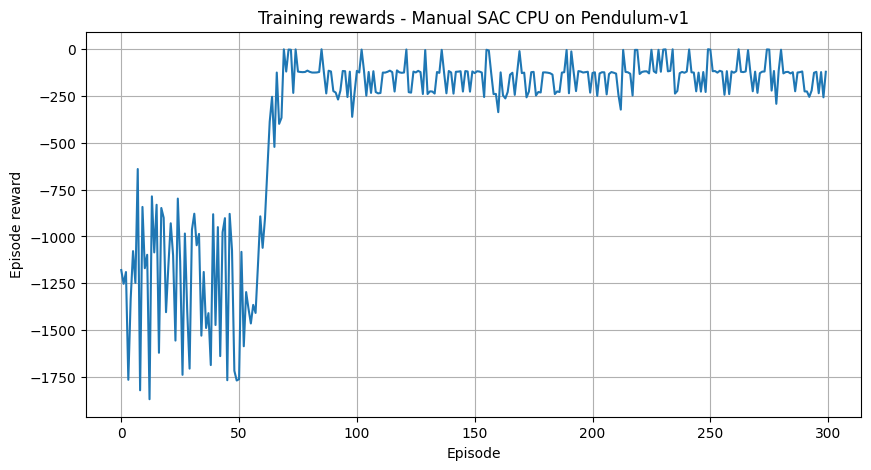

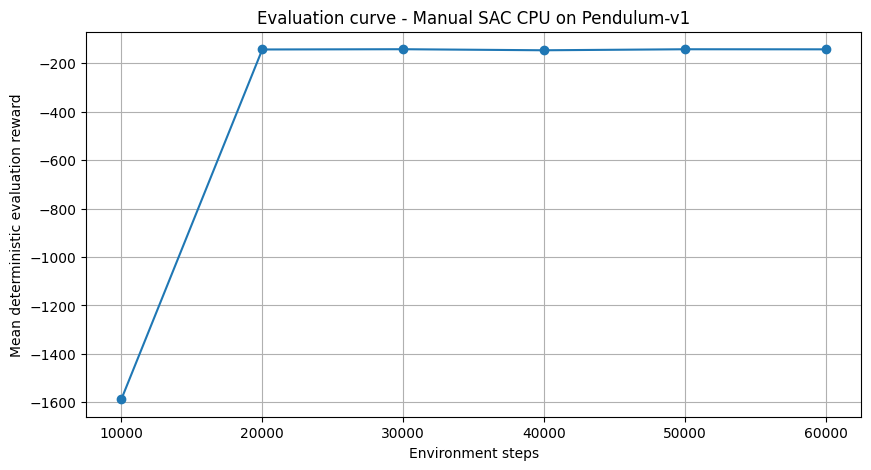

Video reward: -121.55
Video saved at: sac_pendulum_cpu_outputs/sac_pendulum_cpu_final.mp4


In [ ]:
# -----------------------------
# 1) Install / import packages
# -----------------------------
try:
    import gymnasium as gym
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gymnasium[classic-control]", "imageio", "imageio-ffmpeg"])
    import gymnasium as gym

import os
import random
import math
import time
from collections import deque

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
import matplotlib.pyplot as plt
import imageio
from IPython.display import Video, display

# -----------------------------
# 2) Device setting
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------------
# 3) Reproducibility
# -----------------------------
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# -----------------------------
# 4) Hyperparameters
# -----------------------------
ENV_ID = "Pendulum-v1"
TOTAL_STEPS = 180_000          
START_RANDOM_STEPS = 10_000    
BATCH_SIZE = 256
BUFFER_SIZE = 300_000
GAMMA = 0.99
TAU = 0.005
ACTOR_LR = 3e-4
CRITIC_LR = 3e-4
ALPHA_LR = 3e-4
HIDDEN_SIZE = 256
POLICY_UPDATE_FREQ = 1
UPDATES_PER_STEP = 1
EVAL_EVERY = 10_000
EVAL_EPISODES = 20
FINAL_EVAL_EPISODES = 50

SAVE_DIR = "sac_pendulum_cpu_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(SAVE_DIR, "best_sac_pendulum_cpu.pt")
FINAL_MODEL_PATH = os.path.join(SAVE_DIR, "final_sac_pendulum_cpu.pt")
VIDEO_PATH = os.path.join(SAVE_DIR, "sac_pendulum_cpu_final.mp4")

# -----------------------------
# 5) Environment information
# -----------------------------
env = gym.make(ENV_ID)
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.shape[0]
action_low = float(env.action_space.low[0])
action_high = float(env.action_space.high[0])
action_scale = (action_high - action_low) / 2.0
action_bias = (action_high + action_low) / 2.0

print("Observation dim:", obs_dim)
print("Action dim:", act_dim)
print("Action range:", action_low, action_high)

# -----------------------------
# 6) Replay Buffer
# -----------------------------
class ReplayBuffer:
    def __init__(self, obs_dim, act_dim, size):
        self.obs = np.zeros((size, obs_dim), dtype=np.float32)
        self.next_obs = np.zeros((size, obs_dim), dtype=np.float32)
        self.actions = np.zeros((size, act_dim), dtype=np.float32)
        self.rewards = np.zeros((size, 1), dtype=np.float32)
        self.dones = np.zeros((size, 1), dtype=np.float32)
        self.size = size
        self.ptr = 0
        self.full = False

    def add(self, obs, action, reward, next_obs, done):
        self.obs[self.ptr] = obs
        self.actions[self.ptr] = action
        self.rewards[self.ptr] = reward
        self.next_obs[self.ptr] = next_obs
        self.dones[self.ptr] = done
        self.ptr = (self.ptr + 1) % self.size
        if self.ptr == 0:
            self.full = True

    def __len__(self):
        return self.size if self.full else self.ptr

    def sample(self, batch_size):
        max_i = len(self)
        idxs = np.random.randint(0, max_i, size=batch_size)
        batch = dict(
            obs=torch.tensor(self.obs[idxs], dtype=torch.float32, device=device),
            actions=torch.tensor(self.actions[idxs], dtype=torch.float32, device=device),
            rewards=torch.tensor(self.rewards[idxs], dtype=torch.float32, device=device),
            next_obs=torch.tensor(self.next_obs[idxs], dtype=torch.float32, device=device),
            dones=torch.tensor(self.dones[idxs], dtype=torch.float32, device=device),
        )
        return batch

# -----------------------------
# 7) Networks
# -----------------------------
def init_layer(layer):
    nn.init.xavier_uniform_(layer.weight)
    nn.init.constant_(layer.bias, 0.0)
    return layer

class Actor(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_size, action_scale, action_bias):
        super().__init__()
        self.net = nn.Sequential(
            init_layer(nn.Linear(obs_dim, hidden_size)),
            nn.ReLU(),
            init_layer(nn.Linear(hidden_size, hidden_size)),
            nn.ReLU(),
        )
        self.mean = init_layer(nn.Linear(hidden_size, act_dim))
        self.log_std = init_layer(nn.Linear(hidden_size, act_dim))
        self.register_buffer("action_scale", torch.tensor(action_scale, dtype=torch.float32))
        self.register_buffer("action_bias", torch.tensor(action_bias, dtype=torch.float32))

    def forward(self, obs):
        x = self.net(obs)
        mean = self.mean(x)
        log_std = self.log_std(x)
        log_std = torch.clamp(log_std, -20, 2)
        return mean, log_std

    def sample(self, obs):
        mean, log_std = self.forward(obs)
        std = log_std.exp()
        normal = Normal(mean, std)
        x_t = normal.rsample()
        y_t = torch.tanh(x_t)
        action = y_t * self.action_scale + self.action_bias

        log_prob = normal.log_prob(x_t)
        log_prob -= torch.log(self.action_scale * (1 - y_t.pow(2)) + 1e-6)
        log_prob = log_prob.sum(dim=-1, keepdim=True)

        deterministic_action = torch.tanh(mean) * self.action_scale + self.action_bias
        return action, log_prob, deterministic_action

    @torch.no_grad()
    def act(self, obs_np, deterministic=False):
        obs = torch.tensor(obs_np, dtype=torch.float32, device=device).unsqueeze(0)
        action, _, deterministic_action = self.sample(obs)
        out = deterministic_action if deterministic else action
        return out.cpu().numpy()[0]

class Critic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_size):
        super().__init__()
        self.q = nn.Sequential(
            init_layer(nn.Linear(obs_dim + act_dim, hidden_size)),
            nn.ReLU(),
            init_layer(nn.Linear(hidden_size, hidden_size)),
            nn.ReLU(),
            init_layer(nn.Linear(hidden_size, 1)),
        )

    def forward(self, obs, action):
        return self.q(torch.cat([obs, action], dim=-1))

actor = Actor(obs_dim, act_dim, HIDDEN_SIZE, action_scale, action_bias).to(device)
critic1 = Critic(obs_dim, act_dim, HIDDEN_SIZE).to(device)
critic2 = Critic(obs_dim, act_dim, HIDDEN_SIZE).to(device)
target_critic1 = Critic(obs_dim, act_dim, HIDDEN_SIZE).to(device)
target_critic2 = Critic(obs_dim, act_dim, HIDDEN_SIZE).to(device)
target_critic1.load_state_dict(critic1.state_dict())
target_critic2.load_state_dict(critic2.state_dict())

actor_optimizer = torch.optim.Adam(actor.parameters(), lr=ACTOR_LR)
critic1_optimizer = torch.optim.Adam(critic1.parameters(), lr=CRITIC_LR)
critic2_optimizer = torch.optim.Adam(critic2.parameters(), lr=CRITIC_LR)

log_alpha = torch.tensor(0.0, dtype=torch.float32, requires_grad=True, device=device)
alpha_optimizer = torch.optim.Adam([log_alpha], lr=ALPHA_LR)
target_entropy = -float(act_dim)

# -----------------------------
# 8) SAC update step
# -----------------------------
def soft_update(source, target, tau):
    with torch.no_grad():
        for src_p, tgt_p in zip(source.parameters(), target.parameters()):
            tgt_p.data.mul_(1.0 - tau)
            tgt_p.data.add_(tau * src_p.data)

def update_sac(buffer):
    batch = buffer.sample(BATCH_SIZE)
    obs = batch["obs"]
    actions = batch["actions"]
    rewards = batch["rewards"]
    next_obs = batch["next_obs"]
    dones = batch["dones"]

    alpha = log_alpha.exp().detach()

    with torch.no_grad():
        next_actions, next_log_probs, _ = actor.sample(next_obs)
        target_q1 = target_critic1(next_obs, next_actions)
        target_q2 = target_critic2(next_obs, next_actions)
        target_q = torch.min(target_q1, target_q2) - alpha * next_log_probs
        q_backup = rewards + GAMMA * (1.0 - dones) * target_q

    current_q1 = critic1(obs, actions)
    current_q2 = critic2(obs, actions)
    critic1_loss = F.mse_loss(current_q1, q_backup)
    critic2_loss = F.mse_loss(current_q2, q_backup)

    critic1_optimizer.zero_grad()
    critic1_loss.backward()
    critic1_optimizer.step()

    critic2_optimizer.zero_grad()
    critic2_loss.backward()
    critic2_optimizer.step()

    new_actions, log_probs, _ = actor.sample(obs)
    q1_new = critic1(obs, new_actions)
    q2_new = critic2(obs, new_actions)
    q_new = torch.min(q1_new, q2_new)
    alpha_for_actor = log_alpha.exp().detach()
    actor_loss = (alpha_for_actor * log_probs - q_new).mean()

    actor_optimizer.zero_grad()
    actor_loss.backward()
    actor_optimizer.step()

    alpha_loss = -(log_alpha * (log_probs + target_entropy).detach()).mean()
    alpha_optimizer.zero_grad()
    alpha_loss.backward()
    alpha_optimizer.step()

    soft_update(critic1, target_critic1, TAU)
    soft_update(critic2, target_critic2, TAU)

    return {
        "critic1_loss": float(critic1_loss.item()),
        "critic2_loss": float(critic2_loss.item()),
        "actor_loss": float(actor_loss.item()),
        "alpha_loss": float(alpha_loss.item()),
        "alpha": float(log_alpha.exp().item()),
    }

# -----------------------------
# 9) Evaluation
# -----------------------------
def evaluate_policy(actor, episodes=5, seed_offset=1000):
    eval_env = gym.make(ENV_ID)
    scores = []
    for ep in range(episodes):
        obs, _ = eval_env.reset(seed=SEED + seed_offset + ep)
        done = False
        truncated = False
        ep_reward = 0.0
        while not (done or truncated):
            action = actor.act(obs, deterministic=True)
            obs, reward, done, truncated, _ = eval_env.step(action)
            ep_reward += reward
        scores.append(ep_reward)
    eval_env.close()
    return np.array(scores, dtype=np.float32)

# -----------------------------
# 10) Training loop
# -----------------------------
buffer = ReplayBuffer(obs_dim, act_dim, BUFFER_SIZE)

train_rewards = []
eval_steps = []
eval_means = []
best_eval = -float("inf")
recent_rewards = deque(maxlen=10)

obs, _ = env.reset(seed=SEED)
ep_reward = 0.0
ep_len = 0
episode = 1
start_time = time.time()
last_info = {}

print("=" * 90)
print("Training Manual SAC on Pendulum-v1 - CPU only")
print("Total steps:", TOTAL_STEPS)
print("=" * 90)

for step in range(1, TOTAL_STEPS + 1):
    if step <= START_RANDOM_STEPS:
        action = env.action_space.sample()
    else:
        action = actor.act(obs, deterministic=False)

    next_obs, reward, terminated, truncated, _ = env.step(action)

    done_for_buffer = float(terminated)  
    buffer.add(obs, action, reward, next_obs, done_for_buffer)

    obs = next_obs
    ep_reward += reward
    ep_len += 1

    if terminated or truncated:
        train_rewards.append(ep_reward)
        recent_rewards.append(ep_reward)
        if episode % 10 == 0:
            print(
                f"Episode {episode:4d} | Step {step:7d} | "
                f"Reward {ep_reward:9.2f} | Avg10 {np.mean(recent_rewards):9.2f} | "
                f"Alpha {last_info.get('alpha', float('nan')):.4f}"
            )
        obs, _ = env.reset()
        ep_reward = 0.0
        ep_len = 0
        episode += 1

    if len(buffer) >= BATCH_SIZE and step > START_RANDOM_STEPS:
        for _ in range(UPDATES_PER_STEP):
            last_info = update_sac(buffer)

    if step % EVAL_EVERY == 0:
        scores = evaluate_policy(actor, episodes=EVAL_EPISODES)
        mean_score = float(scores.mean())
        eval_steps.append(step)
        eval_means.append(mean_score)
        print("-" * 90)
        print(f"Evaluation at step {step}: mean={mean_score:.2f}, std={scores.std():.2f}, scores={np.round(scores, 2)}")
        print("-" * 90)
        if mean_score > best_eval:
            best_eval = mean_score
            torch.save({
                "actor": actor.state_dict(),
                "critic1": critic1.state_dict(),
                "critic2": critic2.state_dict(),
                "target_critic1": target_critic1.state_dict(),
                "target_critic2": target_critic2.state_dict(),
                "log_alpha": log_alpha.detach().cpu(),
                "best_eval": best_eval,
                "step": step,
            }, BEST_MODEL_PATH)
            print(f"New best model saved: {BEST_MODEL_PATH}")

        if mean_score > -180 and step >= 60_000:
            print("Early stopping: Pendulum is solved well enough.")
            break

elapsed = time.time() - start_time
env.close()
print(f"Training finished in {elapsed/60:.2f} minutes")
print("Best evaluation mean:", best_eval)

torch.save({
    "actor": actor.state_dict(),
    "critic1": critic1.state_dict(),
    "critic2": critic2.state_dict(),
    "target_critic1": target_critic1.state_dict(),
    "target_critic2": target_critic2.state_dict(),
    "log_alpha": log_alpha.detach().cpu(),
    "best_eval": best_eval,
}, FINAL_MODEL_PATH)
print("Final model saved:", FINAL_MODEL_PATH)

if os.path.exists(BEST_MODEL_PATH):
    checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
    actor.load_state_dict(checkpoint["actor"])
    print("Loaded best model from:", BEST_MODEL_PATH)

# -----------------------------
# 11) Final evaluation
# -----------------------------
final_scores = evaluate_policy(actor, episodes=FINAL_EVAL_EPISODES, seed_offset=5000)
print("=" * 90)
print(f"Final deterministic evaluation over {FINAL_EVAL_EPISODES} episodes: mean={final_scores.mean():.2f}, std={final_scores.std():.2f}")
print("Scores:", np.round(final_scores, 2))
print("=" * 90)

# -----------------------------
# 12) Plots
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(train_rewards)
plt.xlabel("Episode")
plt.ylabel("Episode reward")
plt.title("Training rewards - Manual SAC CPU on Pendulum-v1")
plt.grid(True)
plt.show()

if len(eval_steps) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(eval_steps, eval_means, marker="o")
    plt.xlabel("Environment steps")
    plt.ylabel("Mean deterministic evaluation reward")
    plt.title("Evaluation curve - Manual SAC CPU on Pendulum-v1")
    plt.grid(True)
    plt.show()

# -----------------------------
# 13) Create final video
# -----------------------------
def record_video(actor, video_path=VIDEO_PATH, seed=123):
    video_env = gym.make(ENV_ID, render_mode="rgb_array")
    obs, _ = video_env.reset(seed=seed)
    frames = []
    total_reward = 0.0
    done = False
    truncated = False

    while not (done or truncated):
        frame = video_env.render()
        frames.append(frame)
        action = actor.act(obs, deterministic=True)
        obs, reward, done, truncated, _ = video_env.step(action)
        total_reward += reward

    video_env.close()
    imageio.mimsave(video_path, frames, fps=30)
    return total_reward, video_path

video_reward, video_path = record_video(actor)
print(f"Video reward: {video_reward:.2f}")
print("Video saved at:", video_path)
display(Video(video_path, embed=True))